### `list_attr_celeba` Dataset
A popular component of computer vision and deep learning revolves around identifying faces for various applications from logging into your phone with your face or searching through surveillance images for a particular suspect. This dataset is great for training and testing models for face detection, particularly for recognising facial attributes such as finding people with brown hair, are smiling, or wearing glasses. Images cover large pose variations, background clutter, diverse people, supported by a large quantity of images and rich annotations. This data was originally collected by researchers at MMLAB, The Chinese University of Hong Kong (specific reference in Acknowledgment section).



- 202,599 number of face images of various celebrities
- 10,177 unique identities, but names of identities are not given
- 40 binary attribute annotations per image

You can obtain the dataset from https://www.kaggle.com/jessicali9530/celeba-dataset

In [1]:
import numpy as np
import pandas as pd 

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os
import keras
from keras import optimizers
#from keras.preprocessing.image import ImageDataGenerator, load_img, image
#from keras.preprocessing.image import load_img, image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from keras.utils import to_categorical
from keras.models import Model
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization

In [9]:
import os
import pandas as pd

train_dir = '/Users/matthewcavanaugh/Desktop/GitHub/magnimind/Deep Learning/celeb_small 2'

# list only image files (adjust extensions if needed)
filenames = [f for f in os.listdir(train_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# label from filename prefix
categories = ['man' if f.startswith('man') else 'female' for f in filenames]

df = pd.DataFrame({
    'filename': filenames,
    'category': categories
})

print(df.shape)
df.head()

(3801, 2)


,filename,category
0,female.026413.jpg,female
1,female.022675.jpg,female
2,man.033406.jpg,man
3,man.033360.jpg,man
4,female.020704.jpg,female


#### See sample image

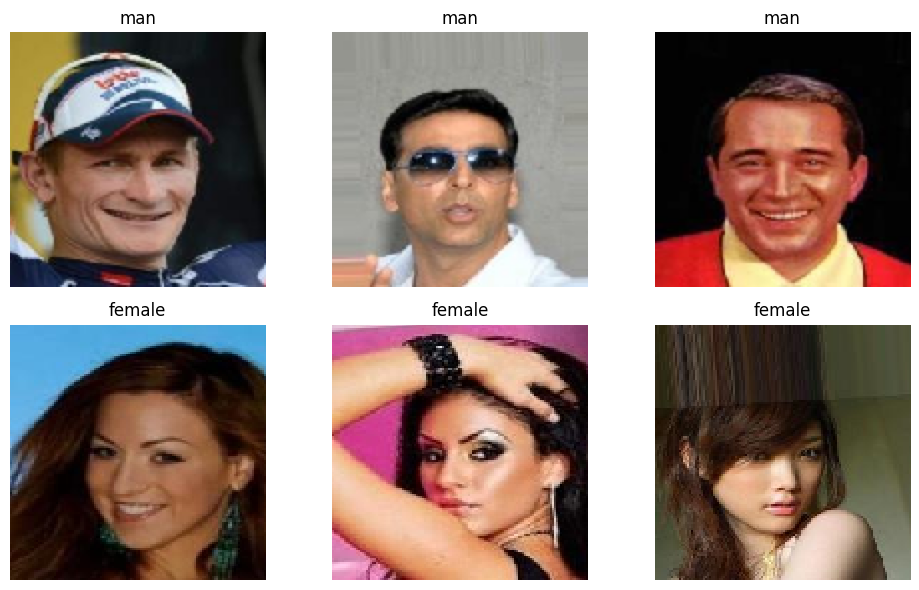

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

IMAGE_SIZE = (128, 128)

plt.figure(figsize=(10, 6))

for i in range(6):
    sample = random.choice(df.index)
    filename = df.loc[sample, 'filename']
    category = df.loc[sample, 'category']
    
    img_path = os.path.join(train_dir, filename)
    image = load_img(img_path, target_size=IMAGE_SIZE)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

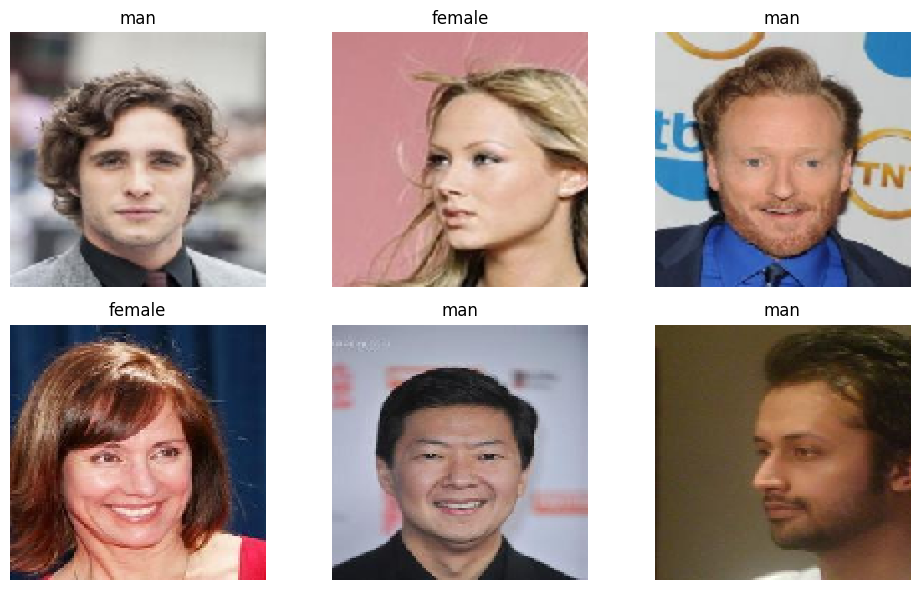

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

IMAGE_SIZE = (128, 128)

plt.figure(figsize=(10, 6))

for i in range(6):
    sample = random.choice(df.index)
    filename = df.loc[sample, 'filename']
    category = df.loc[sample, 'category']
    
    img_path = os.path.join(train_dir, filename)
    image = load_img(img_path, target_size=IMAGE_SIZE)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 4. Build Model

- First, copy VGG16 without the dense layers, use the weights from `imagenet`. Set the input shape to `(178,218,3)`.
- Freeze the layers except the last two layers and print to see if the layers are trainable or not.
- Build your sequential model (you are free to use a functioanl API as a further exercise). Include all the frozen VGG layers to your model. Add a Dense layer with 128 inouts and `relu` activation. Add a batch nomalizer, then a dense layer as the output layer. 
- Create an early stopping criteria monitorin the loss value for the validation set. Stop the search if the loss value deosnt change for two consecutive times.
- Compile the model.
- Save the best model automatically based on the performance of the validation set.

In [24]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

INPUT_SHAPE = (178, 218, 3)

class_mode="binary"

# VGG16 base
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)

# Freeze all layers
for layer in vgg_base.layers:
    layer.trainable = False

# Unfreeze last two layers with weights
unfroze = 0
for layer in reversed(vgg_base.layers):
    if layer.weights:
        layer.trainable = True
        unfroze += 1
        if unfroze == 2:
            break

# Verify trainability
for i, layer in enumerate(vgg_base.layers):
    print(f"{i:02d} {layer.name:25s} trainable={layer.trainable}")

# Build Sequential model
model = Sequential([
    vgg_base,
    Flatten(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dense(1, activation="sigmoid")   # categorical output
])

# Callbacks
earlystop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="best_vgg16_celeb_small.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

00 input_layer_8             trainable=False
01 block1_conv1              trainable=False
02 block1_conv2              trainable=False
03 block1_pool               trainable=False
04 block2_conv1              trainable=False
05 block2_conv2              trainable=False
06 block2_pool               trainable=False
07 block3_conv1              trainable=False
08 block3_conv2              trainable=False
09 block3_conv3              trainable=False
10 block3_pool               trainable=False
11 block4_conv1              trainable=False
12 block4_conv2              trainable=False
13 block4_conv3              trainable=False
14 block4_pool               trainable=False
15 block5_conv1              trainable=False
16 block5_conv2              trainable=True
17 block5_conv3              trainable=True
18 block5_pool               trainable=False


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 15360)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     1,966,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,681,537 (63.64 MB)

 Trainable params: 6,686,209 (25.51 MB)

 Non-trainable params: 9,995,328 (38.13 MB)

## 5. Data Preparation

- Create a validation set with 20% of the data. Check the number of data points per class from both the train and validation sets.
- Set your batch size to 20.
- Create the data generator and set the `preprocessing_function` to `preprocess_input` of VGG16.
- Create train and validation data generators (batches will be picked up from the dataframe). Set target size to (178,218) (you can try something else, but you need to do the corresponding change in the model).
- Set your validation  and epoch step size (`validation_steps` and `steps_per_epoch`)

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# 1) Train/Validation split (20% validation)
train_df, valid_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["category"]  # keeps class balance consistent
)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)

print("\nTrain class counts:")
print(train_df["category"].value_counts())

print("\nValid class counts:")
print(valid_df["category"].value_counts())

# 2) Batch size
BATCH_SIZE = 20

# 3) Image generators (use VGG16 preprocess_input)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# 4) Flow from dataframe
TARGET_SIZE = (178, 218)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=train_dir,
    x_col="filename",
    y_col="category",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",      # two classes -> simplest
    shuffle=True
)

valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=train_dir,
    x_col="filename",
    y_col="category",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("\nclass_indices:", train_generator.class_indices)

# 5) Steps per epoch / validation steps
steps_per_epoch = train_generator.n // train_generator.batch_size
validation_steps = valid_generator.n // valid_generator.batch_size

# If you want to ensure you don't drop the last partial batch, use ceil:
# import math
# steps_per_epoch = math.ceil(train_generator.n / train_generator.batch_size)
# validation_steps = math.ceil(valid_generator.n / valid_generator.batch_size)

print("\nsteps_per_epoch:", steps_per_epoch)
print("validation_steps:", validation_steps)


Train shape: (3040, 2)
Valid shape: (761, 2)

Train class counts:
category
female    1527
man       1513
Name: count, dtype: int64

Valid class counts:
category
female    382
man       379
Name: count, dtype: int64
Found 3040 validated image filenames belonging to 2 classes.
Found 761 validated image filenames belonging to 2 classes.

class_indices: {'female': 0, 'man': 1}

steps_per_epoch: 152
validation_steps: 38


## 6. Train the Model

- Fit the model
- save the model

In [28]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=30,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[earlystop, checkpoint],
    verbose=1
)

Epoch 1/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9746 - loss: 0.0730
Epoch 1: val_loss did not improve from 0.12565
152/152 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.9745 - loss: 0.0731 - val_accuracy: 0.9079 - val_loss: 0.2591
Epoch 2/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9600 - loss: 0.1041
Epoch 2: val_loss did not improve from 0.12565
152/152 ━━━━━━━━━━━━━━━━━━━━ 394s 3s/step - accuracy: 0.9600 - loss: 0.1041 - val_accuracy: 0.9316 - val_loss: 0.1891
Epoch 3/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9845 - loss: 0.0432
Epoch 3: val_loss did not improve from 0.12565
152/152 ━━━━━━━━━━━━━━━━━━━━ 434s 3s/step - accuracy: 0.9845 - loss: 0.0432 - val_accuracy: 0.9566 - val_loss: 0.1268
Epoch 4/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9979 - loss: 0.0128
Epoch 4: val_loss improved from 0.12565 to 0.12383, saving model to best_vgg16_celeb_small.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.9979 - loss:

Patience was set = 2, so it stopped after 2 consecutive epochs with no improvement.